In [11]:
!pip install seaborn
!pip install nltk
!pip install ipywidgets
!pip install wordcloud
!pip install spacy
!python -m spacy download pt_core_news_sm


^C

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
ERROR: Operation cancelled by user

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/local/Cellar/python@3.9/3.9.10/Fr

In [2]:
# Cell 1: Import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from wordcloud import WordCloud
from nltk.util import ngrams
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

# Ensure NLTK resources are downloaded
nltk.download('punkt')
nltk.download('stopwords')

# Set plot styles
%matplotlib inline
sns.set(style='whitegrid')


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/solanotodes/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/solanotodes/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
# Cell 2: Load the Dataset
# Replace 'your_dataset.csv' with the path to your dataset file
df = pd.read_csv('audios_3_0_corrected.csv')

# Display the first few rows to verify data loading
df.head()


,Unnamed: 0,file_name,raw_transcription,audio_id,order,transcription,preprocessing_change,solano_corrections_2
0,0,audios/fff0d959-156a-4313-b3f7-b38a17e4fcba_se...,"Eu viajei tanto, mas eu estava num cruzeiro. E...",fff0d959-156a-4313-b3f7-b38a17e4fcba,0,"Eu viajei tanto, mas eu estava num cruzeiro. E...",False,{}
1,1,audios/fff0d959-156a-4313-b3f7-b38a17e4fcba_se...,"E quando eu cheguei aqui, essa tonteria de mim...",fff0d959-156a-4313-b3f7-b38a17e4fcba,2,"E quando eu cheguei aqui, essa tonteria de mim...",False,{}
2,2,audios/fff0d959-156a-4313-b3f7-b38a17e4fcba_se...,"Não, não consegui te responder. Porque o mal-e...",fff0d959-156a-4313-b3f7-b38a17e4fcba,4,"Não, não consegui te responder. Porque o mal-e...",False,{}
3,3,audios/fff0d959-156a-4313-b3f7-b38a17e4fcba_se...,Cruzeiro foi praticamente até o último dia. El...,fff0d959-156a-4313-b3f7-b38a17e4fcba,1,Cruzeiro foi praticamente até o último dia. El...,False,{}
4,4,audios/fff0d959-156a-4313-b3f7-b38a17e4fcba_se...,E teve alguma coisa que foi boa enquanto você ...,fff0d959-156a-4313-b3f7-b38a17e4fcba,3,E teve alguma coisa que foi boa enquanto você ...,False,{'brinteiro': 'Brintellix'}


In [4]:
# Cell 3: Basic Statistics on the Transcription Column
# Check for missing values
missing_transcriptions = df['transcription'].isnull().sum()
print(f"Number of missing transcriptions: {missing_transcriptions}")

# Total number of transcriptions
total_transcriptions = len(df)
print(f"Total number of transcriptions: {total_transcriptions}")

# Calculate the average length of transcriptions
df['transcription_length'] = df['transcription'].astype(str).apply(len)
average_length = df['transcription_length'].mean()
print(f"Average transcription length (in characters): {average_length:.2f}")


Number of missing transcriptions: 0
Total number of transcriptions: 1374432
Average transcription length (in characters): 103.22


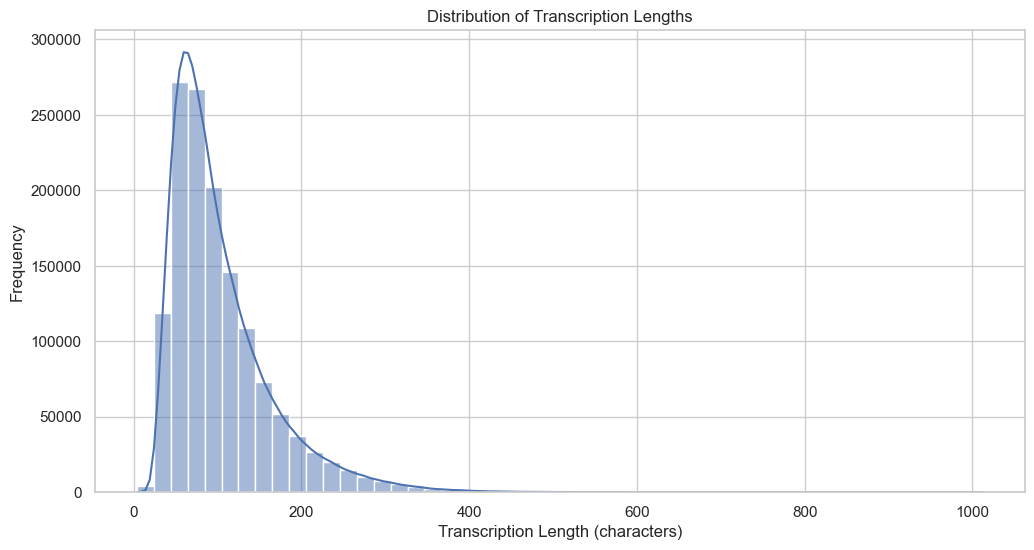

In [6]:
# Cell 4: Distribution of Transcription Lengths
# Plot the distribution
plt.figure(figsize=(12,6))
sns.histplot(df['transcription_length'], bins=50, kde=True)
plt.title('Distribution of Transcription Lengths')
plt.xlabel('Transcription Length (characters)')
plt.ylabel('Frequency')
plt.show()


In [19]:
import ast
# Cell 14: Commonly Corrected Words
# Analyze the 'solano_corrections_2' column to find commonly corrected words

# Function to extract corrections
def extract_corrections(corrections_str):
    try:
        corrections_dict = ast.literal_eval(corrections_str)
        return corrections_dict.items()
    except (ValueError, SyntaxError):
        return []

# Extract all corrections
all_corrections = [item for sublist in df['solano_corrections_2'].apply(extract_corrections) for item in sublist if item]

# Count correction frequencies
correction_freq = Counter([wrong for wrong, correct in all_corrections])


In [20]:
# Display the 20 most commonly corrected words
most_common_corrections = correction_freq.most_common(100)
print("100 Most Commonly Corrected Words:")
for wrong_word, freq in most_common_corrections:
    print(f"{wrong_word}: {freq}")

100 Most Commonly Corrected Words:
S: 3201
E: 1489
R: 752
P: 748
D: 718
N: 619
AD: 597
G: 407
B: 391
T: 363
ar: 344
AR: 286
PR: 282
rio: 279
Ei: 276
PA: 238
M: 237
ER: 216
eletro: 215
ei: 211
testa: 207
X: 199
TI: 196
CO: 195
i: 195
NH: 193
H: 189
I: 178
eco: 168
faxina: 164
Dura: 163
DOS: 158
U: 153
A: 152
card: 149
DI: 149
Zetron: 146
Z: 146
Atenta: 138
elétrico: 138
glifage: 134
Q: 130
BUP: 129
par: 128
IT: 127
ST: 124
SS: 122
atenta: 121
vacina: 120
ESP: 120
madeira: 119
creatina: 119
testo: 119
ex: 116
UI: 113
ação: 110
som: 109
Zenpeak: 109
tenta: 109
Deller: 109
VA: 106
Revoque: 104
revoque: 103
TO: 103
horta: 102
Nã: 101
fome: 100
Rivotril: 100
UE: 99
A,: 99
AP: 98
TA: 98
ser: 97
Ara: 96
B12: 94
Ed: 94
dia: 92
ele: 92
tireoide: 92
Gil: 91
centralina: 90
tom: 90
médio: 89
IP: 89
MP: 88
ketchup: 87
tração: 87
ia: 84
rei: 82
neuro: 81
RQ: 81
pneu: 81
Ozempic: 80
AME: 80
Ansitec: 79
amato: 79
PEG: 79
Li: 77
Peglax: 77
Donaren: 76


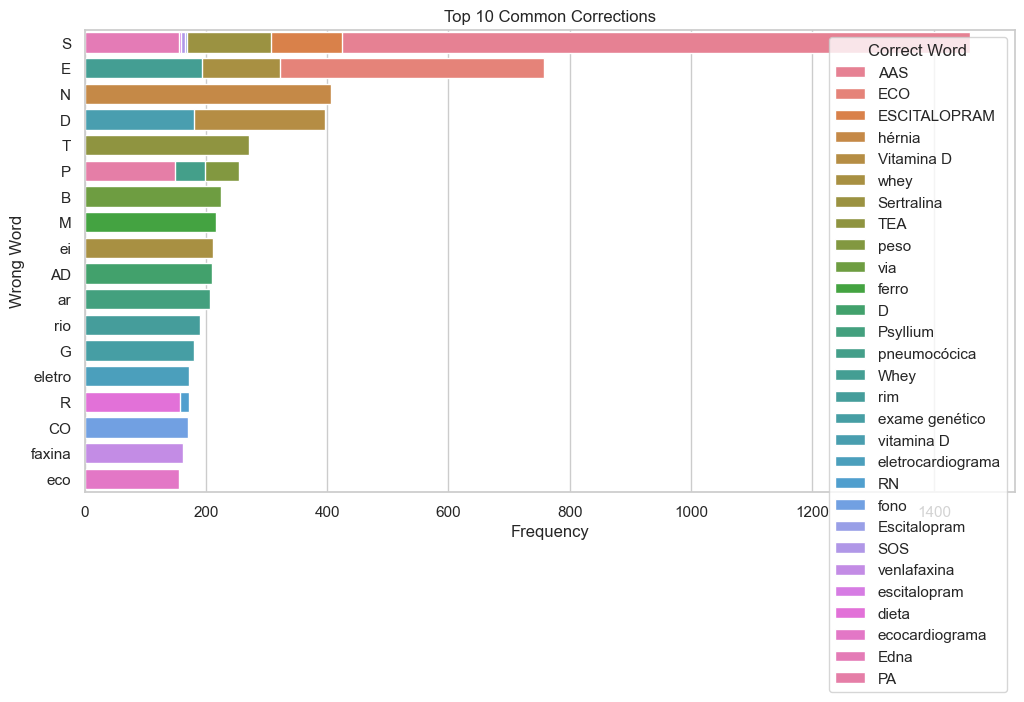

In [21]:
# Cell 15: Visualization of Common Corrections
# Create a DataFrame for the corrections
corrections_df = pd.DataFrame(all_corrections, columns=['wrong_word', 'correct_word'])

# Get the top 10 corrections
top_corrections = corrections_df.groupby(['wrong_word', 'correct_word']).size().reset_index(name='counts')
top_corrections = top_corrections.sort_values(by='counts', ascending=False).head(30)

# Plot the top corrections
plt.figure(figsize=(12,6))
sns.barplot(x='counts', y='wrong_word', hue='correct_word', data=top_corrections, dodge=False)
plt.title('Top 10 Common Corrections')
plt.xlabel('Frequency')
plt.ylabel('Wrong Word')
plt.legend(title='Correct Word')
plt.show()


In [33]:
import pandas as pd

# Load accepted corrections
accepted_df = pd.read_csv('accepted_corrections.csv')
print(f"Total accepted corrections: {len(accepted_df)}")

# Load rejected corrections
rejected_df = pd.read_csv('rejected_corrections.csv')
print(f"Total rejected corrections: {len(rejected_df)}")


Total accepted corrections: 140996
Total rejected corrections: 62534


In [45]:
# Top accepted corrections
top_accepted = accepted_df.groupby(['wrong_word', 'correct_word']).size().reset_index(name='counts')
top_accepted = top_accepted.sort_values(by='counts', ascending=False)[20:40]
print("Top 20 Accepted Corrections:")
print(top_accepted)


Top 20 Accepted Corrections:
        wrong_word  correct_word  counts
42335   centralina    sertralina      68
94330          som          sono      67
51958          dia           DIU      66
13510          Ita          Rita      63
8997            EI            IG      59
50354          dep          dedo      59
54895     elétrico        eletro      57
19744  Papanicolau  Papanicolaou      56
475             AP            AT      56
423             AI            IA      56
89444    remedinho       remédio      54
13270         Inha           Ela      53
73657    meditação     medicação      52
27424       Venvan      Venvanse      50
531             AT            AD      47
24867           TI            QI      47
96866        testa         testo      46
72751       manjar      Mounjaro      45
2030           Ara           Dra      43
7147            DI            QI      43


In [43]:
# Top rejected corrections
top_rejected = rejected_df.groupby(['wrong_word', 'correct_word']).size().reset_index(name='counts')
top_rejected = top_rejected.sort_values(by='counts', ascending=False)[20:40]
print("Top 20 Rejected Corrections:")
print(top_rejected)


Top 20 Rejected Corrections:
      wrong_word    correct_word  counts
9495           S    Escitalopram     169
9496           S             SOS     166
19899     faxina     venlafaxina     162
9500           S    escitalopram     159
8932           R           dieta     158
18502        eco  ecocardiograma     156
9494           S            Edna     155
7986           P              PA     150
10218         TI             UTI     149
3754        Dura      Durateston     149
5127           H            TDAH     147
29748      testa    testosterona     146
3791           E            DHEA     141
21739          i              UI     140
3994          Ei            Whey     138
8928           R              RM     134
4744           G            Jeep     133
3875          ER    ESCITALOPRAM     131
8933           R          hérnia     130
8891           Q           custo     130


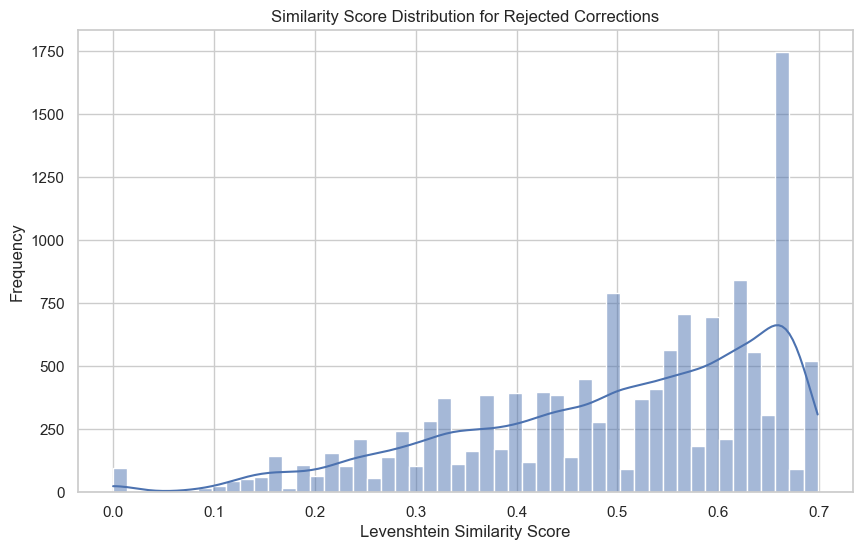

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert similarity scores to numeric
rejected_df['similarity'] = pd.to_numeric(rejected_df['similarity'], errors='coerce')

# Plot similarity score distribution for rejected corrections
plt.figure(figsize=(10,6))
sns.histplot(rejected_df['similarity'], bins=50, kde=True)
plt.title('Similarity Score Distribution for Rejected Corrections')
plt.xlabel('Levenshtein Similarity Score')
plt.ylabel('Frequency')
plt.show()


In [51]:
from huggingface_hub import notebook_login

notebook_login()

In [46]:
from datasets import load_dataset, Audio
hf_audios = load_dataset('voa-engines/voa_audios_3_0', split='train', keep_in_memory=False, num_proc=8)

DatasetNotFoundError: Dataset 'voa-engines/voa_audios_3_0' doesn't exist on the Hub or cannot be accessed.